# HCQVAE

Reimplements the core model from [ikankeu-public/hcqvae](https://github.com/ikankeu-public/hcqvae)
("Hybrid Classical-Quantum Variational Autoencoder for Neural Topic Modeling"), mirroring the
structure of `vae.ipynb` / `qvae.ipynb` (data → model → train → sample → reconstructions →
interpolations).

The official repo is a PennyLane + PyTorch **neural topic modeling** pipeline: a hybrid VAE whose
encoder runs a 10-qubit parameterized quantum circuit (`hybrid vae.py::HybridVAESLS`) to
parameterize the mean and log-variance of a **Gaussian-Softmax** posterior over 20 latent
"topics", with a fully **classical decoder** that reconstructs bag-of-words documents through
topic/word embedding matrices, trained with a multinomial-reconstruction + standard-normal-KL +
topic-decorrelation objective (`utils/trainer.py::VAETrainer._criterion`). It is tied to text
benchmarks (AgNews via HuggingFace `datasets`, 20News via `octis`), GloVe-300 word embeddings via
`gensim`, and topic-coherence evaluation via `octis`/`gensim`, so instead of importing it directly
this notebook ports its load-bearing pieces — the quantum encoder circuit (`AmplitudeEmbedding` →
three `StronglyEntanglingLayers` → Pauli-Z expectations), the Gaussian-Softmax
reparameterization/bottleneck, and the embedding-matrix decoder with its multinomial + KL +
topic-decorrelation loss — as plain differentiable `torch` tensor ops, wired into the same MNIST
pipeline used elsewhere in this survey.

Two faithful, practical swaps keep the model's math unchanged while staying in this survey's
`torch`/`torchvision` stack: **(1)** the encoder's PennyLane `default.qubit` circuit is
reimplemented as a plain statevector simulation in `torch` — every gate (amplitude embedding,
`Rot`, `CNOT`, Pauli-Z measurement) is a differentiable tensor op, so Adam backpropagates through
it exactly as PennyLane's `torch` interface would; **(2)** MNIST replaces the text corpora — each
image is normalized to a distribution over its 784 pixels and treated as a "bag of pixels", the
direct analogue of the repo's bag-of-words document vectors, and since there are no pretrained
embeddings for pixels the topic→300→pixel decoder is initialized randomly instead of from GloVe.
Training uses the repo's own optimizer and objective unchanged (Adam at `lr=2e-3`; multinomial
reconstruction + standard-normal KL + topic-embedding decorrelation penalty).

A **hybrid classical-quantum VAE** here plays the role of a VAE: a classical linear layer
compresses the bag-of-pixels vector, a quantum circuit amplitude-embeds it into a 10-qubit state
and measures Pauli-Z expectations to produce the Gaussian latent's mean and log-variance, a
reparameterized sample is pushed through a Gaussian-softmax into a distribution over 20 latent
topics (the information bottleneck), and a classical embedding-matrix decoder re-expands that topic
distribution into a distribution over pixels. The KL term pulls the Gaussian latent toward a
standard normal — the usual VAE prior.

In [1]:
import math
import pathlib
import sys

import torch
import torch.nn as nn
from torch.nn import functional as F
import torchvision.datasets as datasets

for _root in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_root / "vae" / "models").is_dir():
        sys.path.insert(0, str(_root))
        break

from vae.models.hcqvae import HCQVAE, WIRES
from vae.handlers.hcqvae import to_bag_of_words, elbo_terms, dist_to_image

device = "cuda" if torch.cuda.is_available() else "cpu"

## Data

Same MNIST split used by `vae.ipynb`, but each image is turned into a **bag-of-pixels**
distribution rather than kept as a 2D intensity map, matching the repo's bag-of-words document
inputs (`utils/datasets.py` yields per-document word-count vectors). We flatten each 28×28 image to
a length-784 vector (784 pixel "words") whose entries are the pixel intensities (`/255`) read as
fractional word counts — the total "document length" (≈100) varies from image to image, exactly as
the repo leaves its bag-of-words documents un-normalized. Keeping the counts un-normalized (rather
than rescaling every image to sum 1) is what keeps the multinomial reconstruction term strong enough
for the Gaussian-Softmax bottleneck to stay informative instead of collapsing to the mean image. The
quantum encoder always sees a fixed `2**10 = 1024`-dimensional amplitude vector regardless of vocabulary size,
because the first classical layer (`encoder_fc1024 = nn.Linear(vocab_size, 1024)`) projects the
input to 1024 before amplitude embedding, so no downsampling of the image is needed.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

vocab_size = 28 * 28  # each pixel position is a "word"; each image is a bag-of-pixels

train_dataset = to_bag_of_words(mnist_trainset.data[:-10000])
eval_dataset = to_bag_of_words(mnist_trainset.data[-10000:])

## Amplitude-embedding + strongly-entangling ansatz

Ported from the PennyLane `circuit` in `hybrid vae.py`:
`qml.templates.AmplitudeEmbedding(features, wires=range(10), normalize=True)` followed by
`qml.templates.StronglyEntanglingLayers(weights, wires=range(10))` with `n_layers=3`. We
reimplement both as a plain statevector simulation in `torch`. **Amplitude embedding**
L2-normalizes the (post-`tanh`) 1024-vector and reads it as the `2**10` amplitudes of a 10-qubit
pure state. Each **strongly-entangling layer** applies a `Rot(α,β,γ) = RZ(γ)·RY(β)·RZ(α)` rotation
to every qubit (weights shape `(3, 10, 3)`, exactly `qml.StronglyEntanglingLayers.shape(n_layers=3,
n_wires=10)`) followed by a ring of `CNOT`s with a layer-dependent stride `r = (l mod 9) + 1` —
PennyLane's default `imprimitive=CNOT` and `ranges`. Single-qubit gates act on the statevector by
contracting the target qubit's axis; `CNOT`s are applied as an exact amplitude permutation
(control qubit set ⟹ flip the target bit). Every op is differentiable, so Adam trains the circuit
weights directly, the same way PennyLane's `default.qubit` + `torch` interface would.

## Measurement → Gaussian latent

Ported from the circuit's return value and `HybridVAESLS.encode`. The **SLS** ("small latent
space") variant measures `qml.expval(qml.PauliZ(j))` on each of the 10 qubits, giving a length-10
real vector in `[-1, 1]`; `⟨Z_j⟩ = Σ_k |ψ_k|² · (1 − 2·bit_j(k))`. Two **independent** circuits
produce the posterior mean and log-variance, each scaled by a learnable per-qubit factor
(`mu_alpha`, `log_var_alpha`) and passed through an affine-free `BatchNorm1d`, exactly as in
`encode`. `QuantumLayer` bundles one circuit's parameters and measurement, standing in for the
repo's `qml.qnn.TorchLayer(circuit, weight_shapes)`. (The repo's LLS variant instead measures
`qml.probs` over 5 qubits for a 32-dim latent; we port the flagship SLS variant.)

## Model

`HCQVAE` reproduces `HybridVAESLS` op-for-op: dropout → `Linear(784, 1024)` → `tanh` → two quantum
circuits (mean, log-variance) → learnable per-qubit scale + batch-norm → reparameterize the 10-dim
Gaussian → Gaussian-softmax (`gsm`) into a 20-topic distribution (the latent bottleneck) →
classical decoder `softmax(word_embeddings(topic_embeddings(z)))` mapping topics → a 300-dim
embedding space → a distribution over the 784 pixels. `TOPIC_COUNT = 20` and the 10-qubit width
match the repo's defaults. The only change from the original is that `word_embeddings` is randomly
initialized rather than loaded from GloVe-300, since MNIST pixels have no pretrained embeddings.

## Objective: multinomial reconstruction + standard-normal KL + topic decorrelation

Ported from `utils/trainer.py::VAETrainer._criterion`:
`objective = (reconstruction_loss + KL).mean() + covariance_penalty`. The **reconstruction** term
is the multinomial / cross-entropy negative log-likelihood `−Σ_v log(recon_v)·batch_v` of the
bag-of-pixels counts under the decoder's pixel distribution (the analogue of a VAE's reconstruction
term); the **KL** is the closed-form divergence of the Gaussian latent from a standard normal
(`_standard_normal_kld`, the VAE prior term); and the **topic-decorrelation** `covariance_penalty`
(`_covariance_penalty`) penalizes off-diagonal cosine similarity among the topic embeddings so the
topics stay distinct. The repo weights the KL at 1 throughout; here — as in the other notebooks in
this survey (see `qvae.ipynb`) — we linearly anneal β from 0 to 1 over training, easing the KL
pressure early so the Gaussian-Softmax bottleneck learns to encode the input before the prior term
tightens.

## Training

Mirrors the repo's loop (Adam at `lr=2e-3`, batch size 200, the objective above, with the KL term
β-annealed) but — like `qvae.ipynb` — draws each "epoch" as fresh random subsets of the 50000
training images (`steps_per_epoch` minibatches) rather than the repo's 20 full passes, enough to
move the loss in a couple of minutes on CPU. Increase `steps_per_epoch` / `num_epochs` for a
better-trained model. (The repo also logs topic-coherence metrics each epoch via `octis`; those are
text-specific and omitted here.)

In [3]:
model = HCQVAE(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)  # the repo's optimizer / learning rate

num_epochs = 5        # Change this to train the model a bit more
steps_per_epoch = 100  # Change this to train on more data per epoch
batch_size = 200       # the repo's batch size
beta_max = 1.0
log_every = 20

train_x = train_dataset.to(device)

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_x), (batch_size,), device=device)
        batch = train_x[idx]

        progress = (epoch * steps_per_epoch + step) / (num_epochs * steps_per_epoch)
        beta = min(beta_max, progress * 2)  # linearly anneal the KL weight from 0 to 1

        recon, mu, log_sigma = model(batch)
        recon_l, kld_l, cov_l = elbo_terms(batch, recon, mu, log_sigma, model.get_topic_embeddings())
        loss = recon_l + beta * kld_l + cov_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"recon={recon_l.item():.4f}  kld={kld_l.item():.4f}  cov={cov_l.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 20/100  recon=628.0013  kld=7.9160  cov=0.2198


  epoch 1/5  step 40/100  recon=606.9695  kld=7.5233  cov=0.3632


  epoch 1/5  step 60/100  recon=595.6028  kld=7.4393  cov=0.3833


  epoch 1/5  step 80/100  recon=581.0837  kld=7.2127  cov=0.3763


  epoch 1/5  step 100/100  recon=598.3777  kld=6.9994  cov=0.3685
epoch 1/5  avg loss=606.4596


...

  epoch 5/5  step 20/100  recon=574.5459  kld=5.2542  cov=0.2569


  epoch 5/5  step 40/100  recon=549.4070  kld=5.2423  cov=0.2527


  epoch 5/5  step 60/100  recon=564.7776  kld=5.2781  cov=0.2501


  epoch 5/5  step 80/100  recon=573.5104  kld=5.2661  cov=0.2486


  epoch 5/5  step 100/100  recon=548.1014  kld=5.2857  cov=0.2482
epoch 5/5  avg loss=575.1623


## Visualizing samples

The original repo has no generative sampler (it is trained/evaluated on topic coherence, not
generation). Analogous to `NormalSampler` in `vae.ipynb`, we sample the 10-dim Gaussian latent from
its standard-normal prior — the target the KL term pulls the posterior toward — push it through the
Gaussian-softmax to get a topic distribution, and decode it into a pixel distribution.

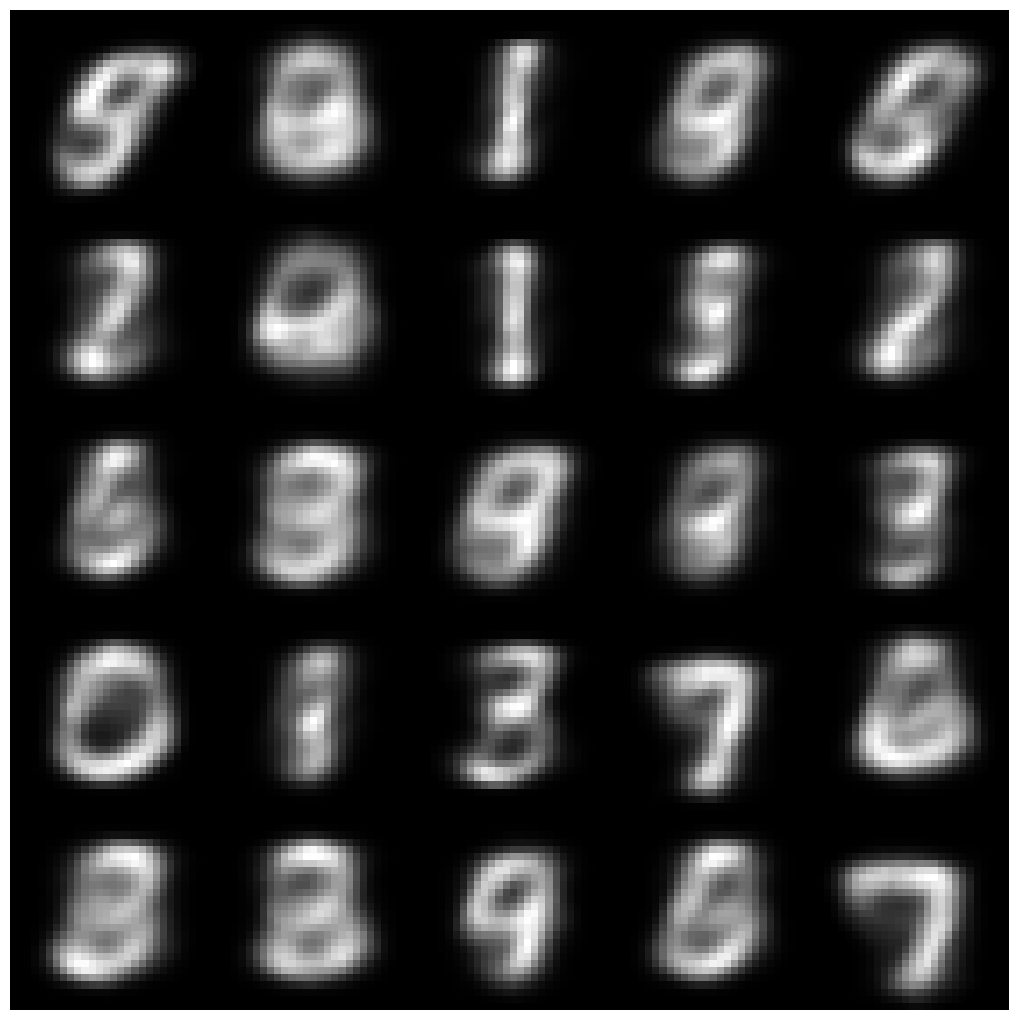

In [4]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    eta = torch.randn(25, WIRES, device=device)  # standard-normal prior on the Gaussian latent
    gen_data = dist_to_image(model.decode(model.gsm(eta))).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

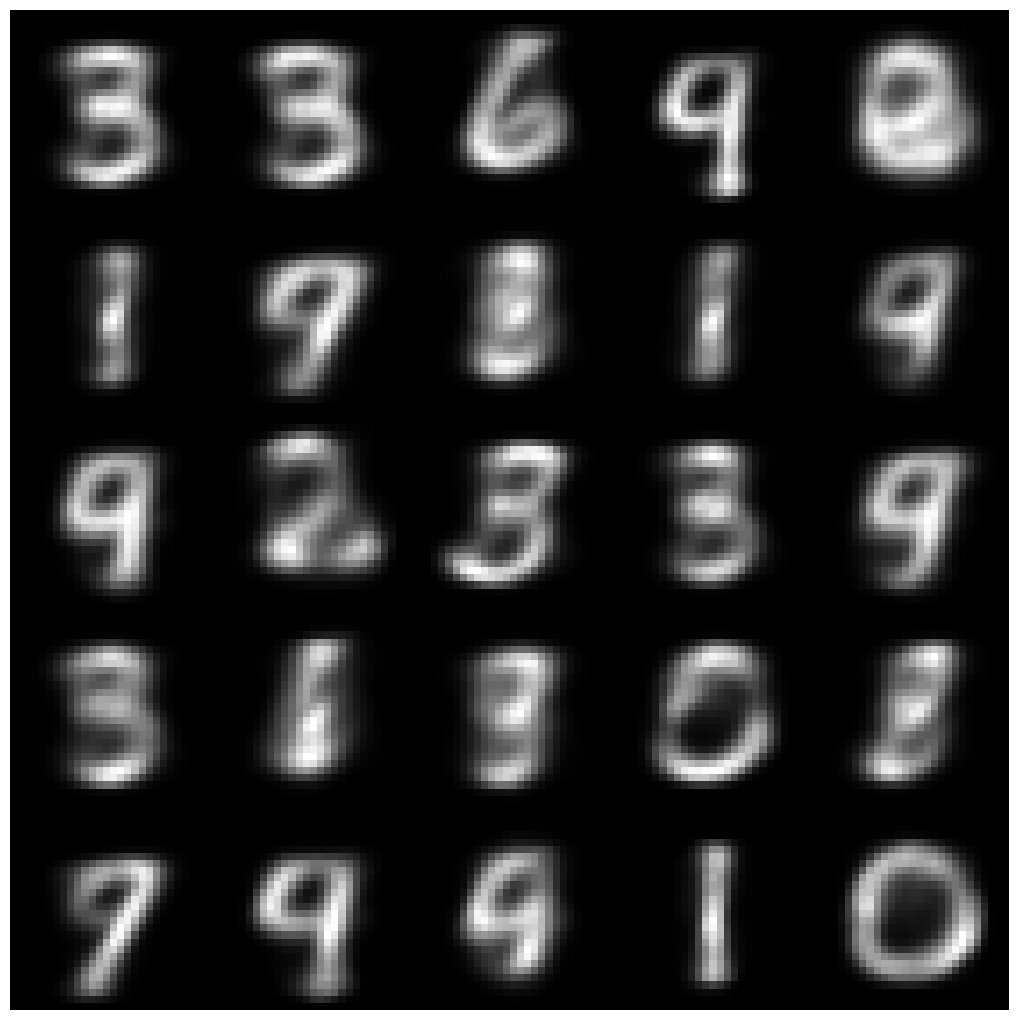

In [5]:
eval_x = eval_dataset[:25].to(device)
model.eval()
with torch.no_grad():
    recon, _, _ = model(eval_x)
    reconstructions = dist_to_image(recon).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

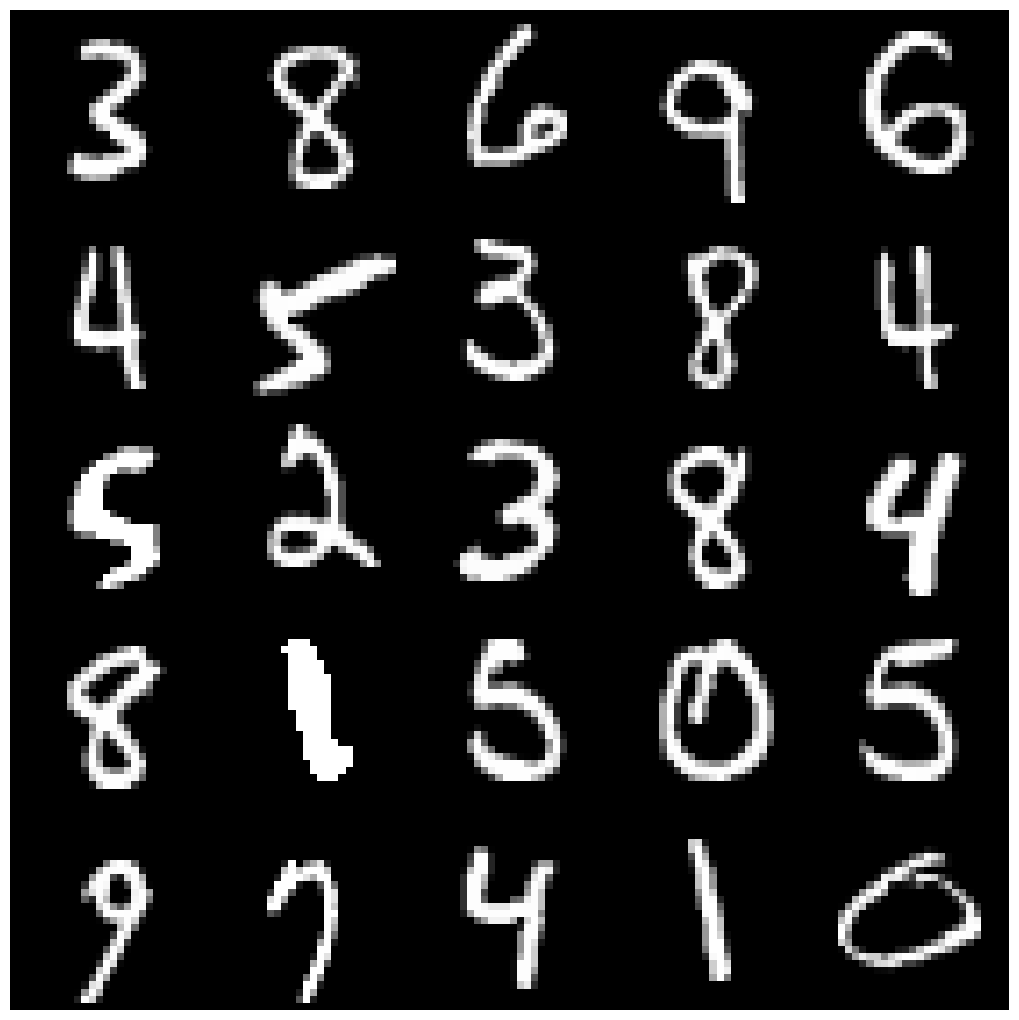

In [6]:
# show the true data
true_images = dist_to_image(eval_x.cpu())

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The official repo has no interpolation utility. Following `vae.ipynb`, we linearly interpolate
between the encoded Gaussian means of two images, decode each interpolated latent through the
Gaussian-softmax and embedding decoder, and view the resulting pixel distributions.

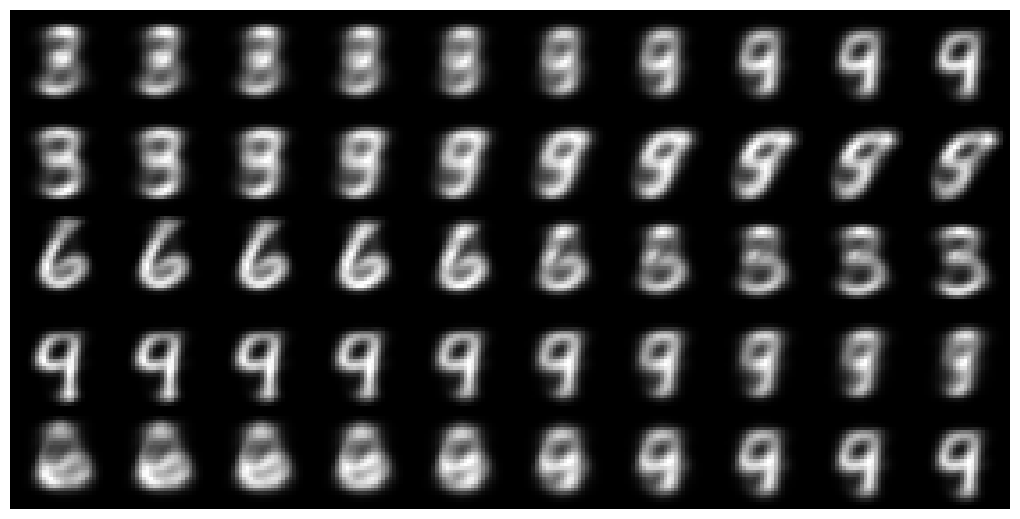

In [7]:
x1 = eval_dataset[:5].to(device)
x2 = eval_dataset[5:10].to(device)

model.eval()
with torch.no_grad():
    mu1, _ = model.encode(x1)
    mu2, _ = model.encode(x2)

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device)
    frames = []
    for a in alphas:
        eta = (1 - a) * mu1 + a * mu2
        frames.append(model.decode(model.gsm(eta)))
    interpolations = torch.stack(frames)  # (granularity, 5, 784)
    interpolations = dist_to_image(interpolations.reshape(-1, vocab_size))
    interpolations = interpolations.reshape(granularity, 5, 28, 28).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)